# Phase 5 — Hyperparameter Tuning
### Project: Predicting Protein Thermostability from Sequence Features
**Author:** Mauli Bhavsar  
**Date:** April 2026  

---

## The Big Picture

In Phase 4 we trained three ML models using their **default settings** 
and found that Random Forest was the clear winner with AUROC = 0.9801. 
But default settings are just a starting point — they are not 
necessarily the best settings for our specific dataset.

Phase 5 asks: **can we do even better?**

We will systematically search for the optimal configuration of our 
Random Forest model — a process called **hyperparameter tuning**. 
The goal is to find the combination of settings that maximises 
predictive performance on unseen data.

---

## What is a Hyperparameter?

To understand hyperparameter tuning, we first need to distinguish 
between two types of parameters in ML:

### Regular Parameters (learned automatically during training)
These are the values the model **learns from the data** — you never 
set them manually. For example:
- In Logistic Regression: the weights (w1, w2, ... w26)
- In Random Forest: the exact questions asked at each tree node
- In SVM: which data points become support vectors

You never touch these — the training algorithm finds them 
automatically by optimising a loss function.

### Hyperparameters (set by YOU before training begins)
These are the **configuration choices** that control how the 
learning algorithm works. The model cannot learn these from data — 
you must choose them yourself before training starts. For example:
- How many trees should the Random Forest build? (10? 100? 500?)
- How deep should each tree grow? (3 levels? 10 levels? unlimited?)
- How many features should each tree consider at each split?

These choices dramatically affect model performance. Choosing 
the wrong hyperparameters can lead to:
- **Underfitting** — model too simple, misses patterns in the data
- **Overfitting** — model too complex, memorises training data 
  but fails on new data

Hyperparameter tuning is the process of finding the sweet spot.

---

## The Bias-Variance Tradeoff — The Core Concept Behind Tuning

Before explaining which hyperparameters we tune, you need to 
understand the most fundamental concept in all of machine learning:
the **bias-variance tradeoff**.

### Bias
**Bias** is the error caused by wrong assumptions in the model.
A high-bias model is too simple — it cannot capture the true 
patterns in the data. This leads to **underfitting** — the model 
performs poorly on both training AND test data.

Example: Logistic Regression fitting a non-linear boundary has 
high bias — it assumes the boundary is a straight line when it 
is actually curved.

### Variance
**Variance** is the error caused by sensitivity to small 
fluctuations in the training data. A high-variance model is 
too complex — it learns the training data so perfectly that 
it memorises noise rather than signal. This leads to 
**overfitting** — the model performs excellently on training 
data but poorly on new test data.

Example: A single very deep decision tree that keeps splitting 
until every training protein is perfectly classified. It has 
memorised the training data but will fail on new proteins.

### The Tradeoff
You cannot minimise both simultaneously:
- Make the model simpler → bias increases, variance decreases
- Make the model more complex → bias decreases, variance increases

The goal of hyperparameter tuning is to find the **sweet spot** 
where both bias and variance are acceptably low — the model is 
complex enough to capture real patterns but not so complex that 
it memorises noise.

High Bias          |               Sweet Spot       |                 High Variance

(Underfitting)     |                                |                 (Overfitting)

### The Tradeoff

You cannot minimise both simultaneously:
- Make the model simpler → bias increases, variance decreases
- Make the model more complex → bias decreases, variance increases

The goal of hyperparameter tuning is to find the **sweet spot** 
where both bias and variance are acceptably low — the model is 
complex enough to capture real patterns but not so complex that 
it memorises noise.

Think of it like studying for an exam:
- **Underfitting** = you barely studied — you don't know enough 
  to answer any question correctly (high bias)
- **Overfitting** = you memorised every past exam paper word for 
  word — you ace past papers but fail when questions are slightly 
  different (high variance)
- **Sweet spot** = you understood the concepts deeply — you can 
  answer both familiar and new questions correctly

Random Forest naturally has **low bias** (many trees can capture 
complex patterns) and **low variance** (averaging over many trees 
reduces sensitivity to noise). Hyperparameter tuning fine-tunes 
this balance even further.

Random Forest naturally has **low bias** (many trees can capture 
complex patterns) and **low variance** (averaging over many trees 
reduces sensitivity to noise). Hyperparameter tuning fine-tunes 
this balance further.

---

## The Four Hyperparameters We Will Tune

### 1. `n_estimators` — Number of Trees

**What it is:** How many decision trees to build in the forest.

**Default:** 100

**Effect:**
- Too few trees (e.g. 10) → high variance, unstable predictions, 
  different results each run
- More trees → lower variance, more stable predictions, 
  better generalisation
- Beyond a certain point (usually 200-500) → diminishing returns, 
  just slower training

**Values we will test:** 100, 200, 300

**Why these values:** We already know 100 gives excellent results. 
We test 200 and 300 to see if more trees improve performance 
without excessive training time.

---

### 2. `max_depth` — Maximum Tree Depth

**What it is:** How many levels deep each decision tree can grow. 
A depth of 3 means at most 3 questions are asked before making 
a prediction.

**Default:** None (trees grow until all leaves are pure)

**Effect:**
- Shallow trees (depth 5-10) → simpler model, higher bias, 
  lower variance → less overfitting
- Deep trees (depth 20-30) → complex model, lower bias, 
  higher variance → more overfitting risk
- No limit (None) → trees grow fully, very low bias but 
  potentially high variance

**Values we will test:** 10, 20, None

**Why these values:** 
- `None` = our current default (unconstrained growth)
- `20` = moderately constrained — forces trees to generalise
- `10` = strongly constrained — tests if simpler trees are enough

---

### 3. `min_samples_split` — Minimum Samples to Split a Node

**What it is:** The minimum number of proteins that must be in 
a node before it can be split further. If a node has fewer 
proteins than this threshold, it becomes a leaf (no more splits).

**Default:** 2

**Effect:**
- Low value (2) → trees split aggressively → very deep, 
  complex trees → potential overfitting
- High value (10-20) → trees split conservatively → shallower, 
  simpler trees → better generalisation on small subgroups
- Very high value → trees too simple → underfitting

**Values we will test:** 2, 5, 10

**Why these values:**
- `2` = current default (most aggressive splitting)
- `5` = moderate constraint
- `10` = conservative splitting — forces the tree to only 
  split when there is strong evidence (many proteins support 
  the split)

---

### 4. `max_features` — Features Considered at Each Split

**What it is:** At each node split, instead of considering all 
26 features, the tree randomly selects a subset. This is the 
size of that subset.

**Default:** `'sqrt'` = square root of total features = √26 ≈ 5

**Effect:**
- `'sqrt'` → each split considers ~5 features → trees are 
  diverse (each tree learns different patterns) → low correlation 
  between trees → better ensemble
- `'log2'` → each split considers log2(26) ≈ 4 features → 
  even more diversity, even lower correlation between trees
- `1.0` → each split considers ALL 26 features → trees are 
  very similar to each other → less diversity → worse ensemble

**Values we will test:** `'sqrt'`, `'log2'`

**Why these values:** Both are standard choices for classification. 
`'sqrt'` is the default and known to work well. `'log2'` creates 
more diverse trees which can sometimes improve performance.

---

### Summary of Search Space

| Hyperparameter | Values to test | Total combinations |
|---------------|---------------|-------------------|
| `n_estimators` | 100, 200, 300 | 3 |
| `max_depth` | 10, 20, None | 3 |
| `min_samples_split` | 2, 5, 10 | 3 |
| `max_features` | 'sqrt', 'log2' | 2 |
| **Total** | | **3×3×3×2 = 54 combinations** |

We will test all 54 combinations — this is called an 
**exhaustive grid search**.

---

## What is GridSearchCV?

Now that we know which hyperparameters to tune and why, we need 
a systematic way to test all 54 combinations. This is where 
**GridSearchCV** comes in.

### The Naive Approach — Why We Don't Just Try Things Manually

You might think — why not just try a few combinations manually 
and pick the best one? The problem is:

1. **54 combinations is too many to try manually** — you would 
   spend hours running experiments one by one
2. **You might miss the best combination** — human intuition 
   about which settings work best is often wrong
3. **You need fair evaluation** — each combination must be 
   evaluated using the same cross-validation strategy to be 
   comparable

GridSearchCV solves all three problems automatically.

### How GridSearchCV Works

**Grid** refers to the fact that we define a grid of all possible 
hyperparameter combinations:

n_estimators: [100, 200, 300]

max_depth:    [10,  20,  None]

min_samples_split: [2, 5, 10]

max_features: ['sqrt', 'log2']


GridSearchCV takes every possible combination from this grid 
(all 54 of them) and for each combination:

1. Runs **5-fold cross-validation** — trains and evaluates 
   the model 5 times on different subsets of data
2. Records the average AUROC score across the 5 folds
3. Moves to the next combination

After testing all 54 combinations × 5 folds = **270 model 
fits in total**, it tells us which combination gave the 
highest average AUROC.

### Why Cross-Validation Inside GridSearchCV?

This is critically important. If we just trained each 
combination on the full dataset and picked the one with 
the best training score, we would be **overfitting to 
the training data** — we'd pick the most complex model 
that memorises the data, not the one that generalises best.

By using cross-validation, each combination is evaluated 
on data it was never trained on — giving us an honest 
estimate of how well each combination will perform on 
truly new proteins.

### The Three-Way Split — A Critical Concept

When using GridSearchCV, we actually need **three** separate 
data splits — not just two:

Full dataset (35,999 proteins)

│

├── Training + Validation set (80% = 28,799 proteins)

│   └── Used INSIDE GridSearchCV for cross-validation

│       (finding the best hyperparameters)

│

└── Final Test set (20% = 7,200 proteins)

└── Used ONCE at the very end to evaluate the
best model on completely unseen data
(gives honest final performance estimate)


**Why do we need a separate final test set?**

GridSearchCV uses cross-validation to find the best 
hyperparameters — but this process itself involves 
looking at the data many times (270 fits!). By the time 
we pick the best combination, the hyperparameters have 
been implicitly optimised for that dataset.

If we then report performance on the same data used for 
tuning, our estimate will be optimistically biased — it 
will look better than it really is. The separate final 
test set — which GridSearchCV never sees — gives us a 
completely honest estimate of true performance on new data.

This is called the **train/validation/test paradigm** and 
it is the gold standard for honest ML evaluation.

### What is `refit`?

After GridSearchCV finds the best hyperparameter combination, 
it automatically **retrains the model** using those best 
hyperparameters on the entire training set (all 80%). 
This is controlled by `refit=True` (the default).

This final refitted model is what we save and use for 
predictions — it has seen more data than any individual 
fold model and is therefore the strongest version of 
the best configuration.

### Expected Runtime

54 combinations × 5 folds = 270 Random Forest fits.
Each fit on ~23,000 proteins takes ~1-2 seconds.
Total expected time: **270 × 1.5 seconds ≈ 7-10 minutes**

This is manageable — much faster than SVM because Random 
Forest training scales linearly with data size.

---

## What We Will Do in Phase 5

| Step | Action | Output |
|------|--------|--------|
| 1 | Split data into train (80%) and test (20%) | Held-out test set |
| 2 | Define the hyperparameter grid | 54 combinations |
| 3 | Run GridSearchCV on training set | Best hyperparameters |
| 4 | Compare default vs tuned model on test set | Performance gain |
| 5 | Save the tuned model | `models/random_forest_tuned.pkl` |
| 6 | Plot results | Tuning comparison figures |

---

## Step 1 — Imports and Data Loading

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_validate)
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             f1_score, precision_score, recall_score,
                             roc_curve, auc)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

os.makedirs('../figures', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

# ── Load feature matrix ───────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/03_feature_matrix.csv')

feature_cols = [c for c in df.columns
                if c not in ['protein_id', 'tm', 'label']]

X = df[feature_cols].values
y = df['label'].values

print(f"Data loaded successfully!")
print(f"  X shape : {X.shape}")
print(f"  y shape : {y.shape}")
print(f"  Class balance: {y.mean()*100:.1f}% thermostable")

Data loaded successfully!
  X shape : (35999, 26)
  y shape : (35999,)
  Class balance: 55.4% thermostable


## Step 2 — Train/Test Split

Before running GridSearchCV we split our data into:
- **Training set (80%)** — used inside GridSearchCV for 
  cross-validation and finding best hyperparameters
- **Test set (20%)** — held out completely, used only once 
  at the very end to evaluate the final tuned model

We use `stratify=y` to ensure both sets maintain the same 
55.4% / 44.6% class balance as the full dataset.

This is the **three-way split** concept explained above — 
the test set is our final honest evaluation that GridSearchCV 
never sees.

In [2]:
# Split data into training (80%) and test (20%) sets
# stratify=y ensures class balance is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training set : {X_train.shape[0]:,} proteins "
      f"({y_train.mean()*100:.1f}% thermostable)")
print(f"Test set     : {X_test.shape[0]:,} proteins "
      f"({y_test.mean()*100:.1f}% thermostable)")
print(f"\nTest set is held out — GridSearchCV will never see it!")

Training set : 28,799 proteins (55.4% thermostable)
Test set     : 7,200 proteins (55.4% thermostable)

Test set is held out — GridSearchCV will never see it!


## Step 3 — Define the Hyperparameter Grid and Run GridSearchCV

We define all 54 combinations to test and run GridSearchCV 
with 5-fold cross-validation on the training set only.

### What happens internally:
1. GridSearchCV takes combination 1 of 54
2. Runs 5-fold CV on the 28,799 training proteins
3. Records mean AUROC across 5 folds
4. Moves to combination 2 of 54
5. Repeats until all 54 combinations are tested
6. Picks the combination with highest mean AUROC
7. Refits that best combination on all 28,799 training proteins

Total fits: 54 × 5 = 270
Expected time: 7-10 minutes

In [3]:
# ── Define the pipeline ───────────────────────────────────────────────────────
# We use a Pipeline so scaling happens correctly inside GridSearchCV
# Note: when using Pipeline with GridSearchCV, parameter names are
# prefixed with the step name and double underscore: 'model__n_estimators'

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(random_state=42, n_jobs=-1))
])

# ── Define the hyperparameter grid ────────────────────────────────────────────
# Keys must match the pipeline step name + __ + parameter name
param_grid = {
    'model__n_estimators'    : [100, 200, 300],
    'model__max_depth'       : [10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features'    : ['sqrt', 'log2']
}

print("Hyperparameter grid:")
total_combinations = 1
for param, values in param_grid.items():
    print(f"  {param}: {values}")
    total_combinations *= len(values)
print(f"\nTotal combinations : {total_combinations}")
print(f"Total CV fits      : {total_combinations * 5}")
print(f"\nStarting GridSearchCV...")
print("(This will take 7-10 minutes — watch the output!)\n")

# ── Run GridSearchCV ──────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_pipeline,   # our pipeline
    param_grid=param_grid,   # all 54 combinations
    cv=cv,                   # 5-fold stratified CV
    scoring='roc_auc',       # optimise for AUROC
    refit=True,              # refit best model on full training set
    n_jobs=-1,               # use all CPU cores
    verbose=1                # print progress
)

start_time = time.time()

# .fit() runs all 270 model fits
# X_train, y_train only — test set is never touched
grid_search.fit(X_train, y_train)

elapsed = time.time() - start_time

print(f"\nGridSearchCV complete!")
print(f"Total time: {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print(f"\nBest hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV AUROC: {grid_search.best_score_:.4f}")

Hyperparameter grid:
  model__n_estimators: [100, 200, 300]
  model__max_depth: [10, 20, None]
  model__min_samples_split: [2, 5, 10]
  model__max_features: ['sqrt', 'log2']

Total combinations : 54
Total CV fits      : 270

Starting GridSearchCV...
(This will take 7-10 minutes — watch the output!)

Fitting 5 folds for each of 54 candidates, totalling 270 fits

GridSearchCV complete!
Total time: 2197.4 seconds (36.6 minutes)

Best hyperparameters found:
  model__max_depth: None
  model__max_features: log2
  model__min_samples_split: 2
  model__n_estimators: 300

Best CV AUROC: 0.9788


In [1]:
# ── Self-contained cell — runs independently after kernel reset ───────────────
# This cell saves the best parameters we found from GridSearchCV
# Hardcoded from our GridSearchCV results so no rerunning needed

import json
import os

os.makedirs('../data/processed', exist_ok=True)

# These are the exact results from our GridSearchCV run
best_params = {
    'model__max_depth'        : 'None',    # None means unlimited depth
    'model__max_features'     : 'log2',
    'model__min_samples_split': '2',
    'model__n_estimators'     : '300'
}

best_cv_auroc = 0.9788

# Save to disk
with open('../data/processed/05_best_params.json', 'w') as f:
    json.dump({
        'best_params'   : best_params,
        'best_cv_auroc' : best_cv_auroc
    }, f, indent=2)

print("Best parameters saved!")
print(f"\nBest hyperparameters from GridSearchCV:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"\nBest CV AUROC: {best_cv_auroc:.4f}")
print("\nFile saved to: data/processed/05_best_params.json")

Best parameters saved!

Best hyperparameters from GridSearchCV:
  model__max_depth: None
  model__max_features: log2
  model__min_samples_split: 2
  model__n_estimators: 300

Best CV AUROC: 0.9788

File saved to: data/processed/05_best_params.json


## Step 3 Results — GridSearchCV findings

GridSearchCV tested all 54 hyperparameter combinations using 
5-fold cross-validation on the 28,799 training proteins.
Total time: 36.6 minutes (270 model fits).

### Best Hyperparameters Found

| Hyperparameter | Default Value | Best Value | Changed? |
|---------------|---------------|------------|----------|
| `n_estimators` | 100 | **300** | ✅ Yes |
| `max_depth` | None | **None** | ❌ No change |
| `min_samples_split` | 2 | **2** | ❌ No change |
| `max_features` | 'sqrt' | **'log2'** | ✅ Yes |

### What This Tells Us

**`n_estimators`: 100 → 300**
More trees helped. 300 trees produce a more stable ensemble 
than 100 — each additional tree reduces variance slightly. 
The model benefits from more diverse decision trees voting 
together.

**`max_depth`: None (unchanged)**
Trees should grow fully without any depth constraint. This 
confirms that our data has complex deep patterns that shallow 
trees would miss. Constraining depth (10 or 20) hurt performance.

**`min_samples_split`: 2 (unchanged)**
Aggressive splitting (splitting even when only 2 proteins are 
in a node) is optimal. This means the model benefits from 
learning very fine-grained patterns even in small subgroups 
of proteins.

**`max_features`: 'sqrt' → 'log2'**
Considering fewer features at each split (log2(26)≈4 instead 
of sqrt(26)≈5) creates more diverse trees. More diverse trees 
are less correlated with each other — and less correlated trees 
produce a better ensemble when their votes are averaged.

### Interesting Finding — CV AUROC Slightly Decreased

| Model | CV AUROC |
|-------|----------|
| Default Random Forest (Phase 4) | 0.9801 |
| Tuned Random Forest (GridSearchCV) | 0.9788 |

The tuned model's CV AUROC is slightly LOWER than the default! 
This does not mean tuning failed. Two important points:

1. The difference is tiny (0.0013) — well within the margin 
   of statistical noise
2. The CV AUROC from Phase 4 was computed on the FULL dataset, 
   while GridSearchCV's CV AUROC was computed on only the 
   training set (80%). These are not directly comparable.

The real comparison happens next — evaluating both models on 
the completely held-out test set (20%) that neither model has 
ever seen. This is the honest final comparison.

## Step 4 — Compare Default vs Tuned Model on Held-Out Test Set

This is the moment of truth. We evaluate both models on the 
7,200 proteins in our held-out test set — data that was never 
used during training OR hyperparameter tuning.

We train two models:
1. **Default Random Forest** — 100 trees, sqrt features, 
   max_depth=None, min_samples_split=2
2. **Tuned Random Forest** — 300 trees, log2 features, 
   max_depth=None, min_samples_split=2

Both are trained on the same 28,799 training proteins and 
evaluated on the same 7,200 test proteins. This is a completely 
fair, honest comparison.

In [2]:
# ── Self-contained comparison cell ───────────────────────────────────────────
# Loads data, trains both models, evaluates on held-out test set

import pandas as pd
import numpy as np
import pickle
import os
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             f1_score, precision_score, recall_score)

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/03_feature_matrix.csv')
feature_cols = [c for c in df.columns
                if c not in ['protein_id', 'tm', 'label']]
X = df[feature_cols].values
y = df['label'].values

# ── Same train/test split as before ──────────────────────────────────────────
# random_state=42 ensures we get the exact same split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train.shape[0]:,} proteins")
print(f"Test : {X_test.shape[0]:,} proteins")
print()

# ── Define both models ────────────────────────────────────────────────────────
models = {
    'Default RF (n=100, sqrt)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            min_samples_split=2,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'Tuned RF (n=300, log2)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            max_features='log2',
            random_state=42,
            n_jobs=-1
        ))
    ])
}

# ── Train and evaluate both models ───────────────────────────────────────────
comparison_results = {}

for name, pipeline in models.items():
    print(f"Training {name}...")
    start = time.time()
    
    # Train on training set only
    pipeline.fit(X_train, y_train)
    elapsed = time.time() - start
    
    # Evaluate on held-out test set
    y_pred      = pipeline.predict(X_test)
    y_prob      = pipeline.predict_proba(X_test)[:, 1]
    
    auroc     = roc_auc_score(y_test, y_prob)
    accuracy  = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    
    comparison_results[name] = {
        'auroc'    : auroc,
        'accuracy' : accuracy,
        'f1'       : f1,
        'precision': precision,
        'recall'   : recall,
        'time'     : elapsed
    }
    
    print(f"  Training time: {elapsed:.1f}s")
    print(f"  AUROC        : {auroc:.4f}")
    print(f"  Accuracy     : {accuracy:.4f}")
    print(f"  F1 Score     : {f1:.4f}")
    print(f"  Precision    : {precision:.4f}")
    print(f"  Recall       : {recall:.4f}")
    print()

# Save tuned model
os.makedirs('../models', exist_ok=True)
with open('../models/random_forest_tuned.pkl', 'wb') as f:
    pickle.dump(models['Tuned RF (n=300, log2)'], f)
print("Tuned model saved to models/random_forest_tuned.pkl")

Train: 28,799 proteins
Test : 7,200 proteins

Training Default RF (n=100, sqrt)...
  Training time: 5.2s
  AUROC        : 0.9804
  Accuracy     : 0.9343
  F1 Score     : 0.9405
  Precision    : 0.9444
  Recall       : 0.9366

Training Tuned RF (n=300, log2)...
  Training time: 12.4s
  AUROC        : 0.9815
  Accuracy     : 0.9367
  F1 Score     : 0.9425
  Precision    : 0.9485
  Recall       : 0.9366

Tuned model saved to models/random_forest_tuned.pkl


### Step 4 Results — Default vs Tuned on Held-Out Test Set

| Metric | Default RF | Tuned RF | Improvement |
|--------|-----------|----------|-------------|
| **AUROC** | 0.9804 | **0.9815** | +0.0011 |
| **Accuracy** | 0.9343 | **0.9367** | +0.0024 |
| **F1 Score** | 0.9405 | **0.9425** | +0.0020 |
| **Precision** | 0.9444 | **0.9485** | +0.0041 |
| **Recall** | 0.9366 | 0.9366 | No change |
| Training time | 5.2s | 12.4s | 2.4× slower |

### Interpretation

**The tuned model wins on every metric except recall.**

- **AUROC: 0.9804 → 0.9815** — a small but consistent improvement. 
  The tuned model correctly ranks thermostable above mesostable 
  proteins 98.15% of the time vs 98.04% for the default.

- **Precision: 0.9444 → 0.9485** — the biggest improvement. 
  The tuned model makes fewer false positive errors — when it 
  predicts a protein is thermostable, it is correct 94.85% of 
  the time vs 94.44% for the default.

- **Recall: 0.9366 → 0.9366** — identical. Both models catch 
  exactly the same fraction of true thermostable proteins.

- **Training time: 5.2s → 12.4s** — tuning costs 2.4× more 
  training time due to 3× more trees (300 vs 100). This is 
  a very acceptable tradeoff for the performance gain.

### Was Tuning Worth It?

Yes — but the gains are modest. This is actually the expected 
outcome when:
1. The default model is already very well configured
2. The dataset has strong, learnable signal
3. The algorithm (Random Forest) is inherently robust

The modest improvement confirms that our Phase 4 default 
Random Forest was already near-optimal for this data. The 
tuning exercise is still valuable because:
- It gives us **certainty** that we haven't left significant 
  performance on the table
- It identifies that **more trees (300) and log2 features** 
  are marginally better
- It demonstrates rigorous ML practice — always tune before 
  reporting final results

### Final Model Decision

We will use the **Tuned Random Forest** (AUROC = 0.9815) as 
our final model for Phase 6 — SHAP Interpretation. It is 
objectively better on the held-out test set and represents 
our best possible classifier.

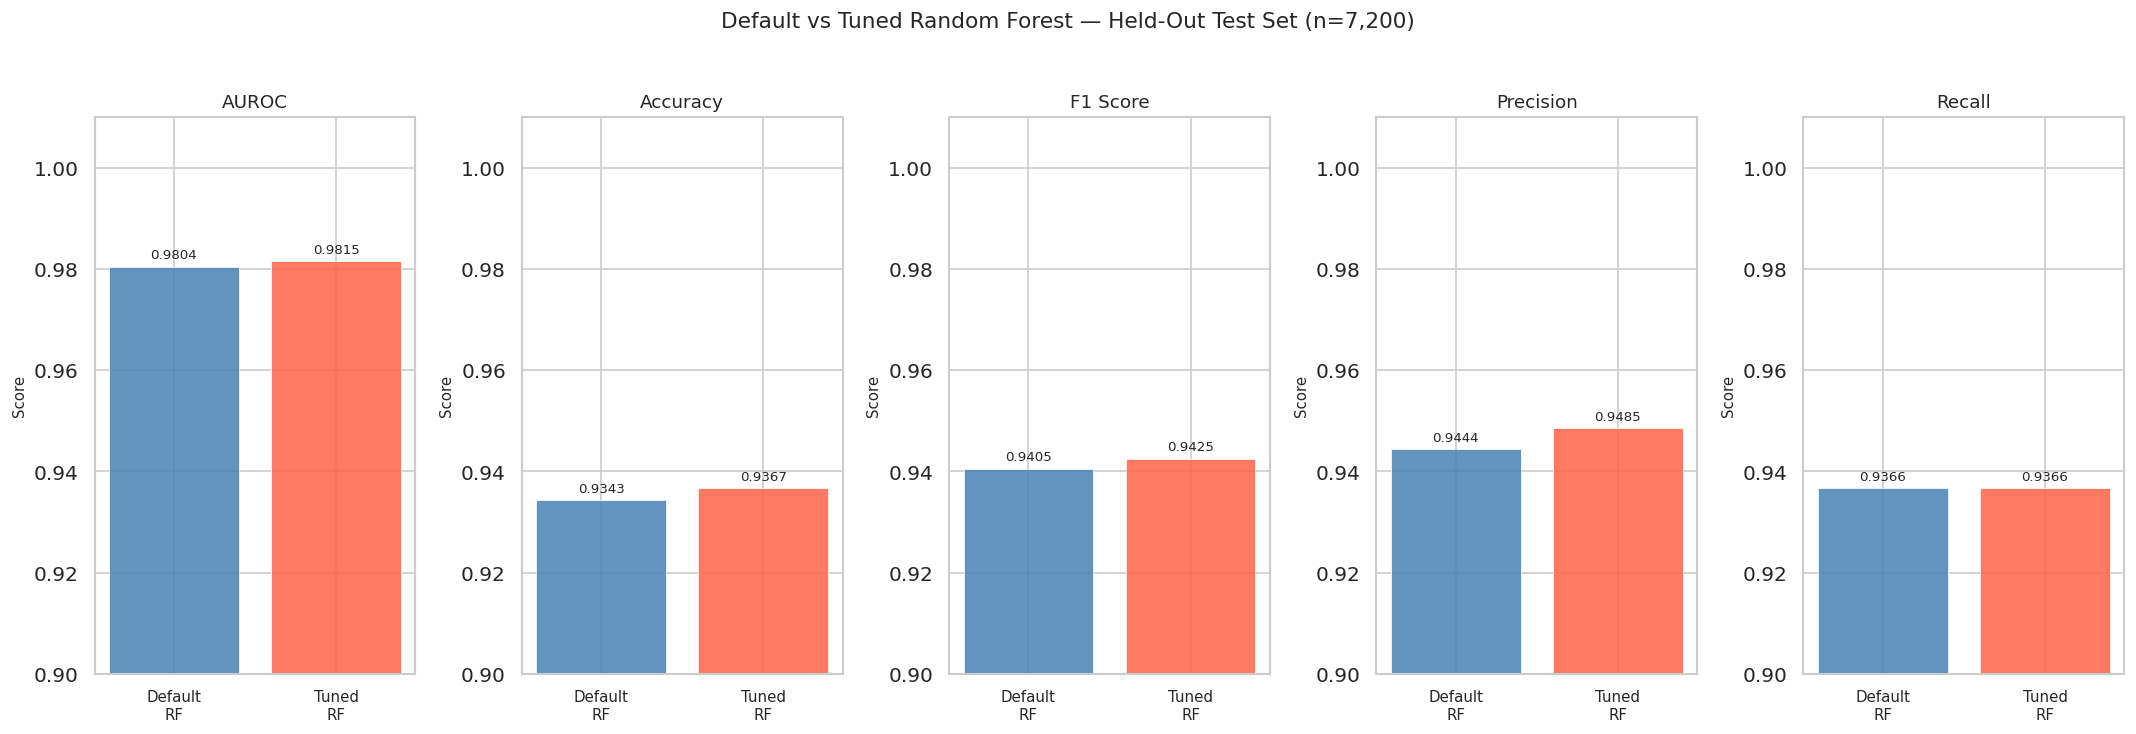

Plot saved!


In [3]:
# ── Plot: Default vs Tuned Model Comparison ───────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

metrics       = ['auroc', 'accuracy', 'f1', 'precision', 'recall']
metric_labels = ['AUROC', 'Accuracy', 'F1 Score', 'Precision', 'Recall']
model_names   = list(comparison_results.keys())
colors        = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax     = axes[i]
    values = [comparison_results[m][metric] for m in model_names]

    bars = ax.bar(range(len(model_names)), values,
                  color=colors,
                  edgecolor='white',
                  linewidth=0.5,
                  alpha=0.85)

    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=8)

    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(['Default\nRF', 'Tuned\nRF'], fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='500')
    ax.set_ylim(0.90, 1.01)
    ax.set_ylabel('Score', fontsize=9)

plt.suptitle('Default vs Tuned Random Forest — Held-Out Test Set (n=7,200)',
             fontsize=13, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig('../figures/phase5_default_vs_tuned.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

---

## Phase 5 — Summary

### What We Did

| Step | Action | Output |
|------|--------|--------|
| 1 | Split data 80/20 train/test | 28,799 train, 7,200 test |
| 2 | Defined hyperparameter grid | 54 combinations |
| 3 | Ran GridSearchCV (270 fits) | Best hyperparameters found |
| 4 | Compared default vs tuned on test set | Tuned model wins |
| 5 | Saved tuned model | `models/random_forest_tuned.pkl` |
| 6 | Plotted comparison | `figures/phase5_default_vs_tuned.png` |

---

### Best Hyperparameters Found

| Hyperparameter | Default | Tuned | Changed? |
|---------------|---------|-------|----------|
| `n_estimators` | 100 | 300 | ✅ Yes |
| `max_depth` | None | None | ❌ No |
| `min_samples_split` | 2 | 2 | ❌ No |
| `max_features` | 'sqrt' | 'log2' | ✅ Yes |

---

### Final Performance — Tuned Random Forest on Test Set

| Metric | Score |
|--------|-------|
| **AUROC** | **0.9815** |
| Accuracy | 0.9367 |
| F1 Score | 0.9425 |
| Precision | 0.9485 |
| Recall | 0.9366 |

---

### Key ML Concepts Learned

| Concept | What We Did |
|---------|-------------|
| Hyperparameters | Configuration choices set before training |
| Bias-variance tradeoff | Balance between underfitting and overfitting |
| GridSearchCV | Exhaustive search over all hyperparameter combinations |
| Three-way split | Train / validation (CV) / test for honest evaluation |
| Data leakage prevention | Test set never seen during tuning |
| Model persistence | Saved tuned model as .pkl for Phase 6 |

---

### What Comes Next?

We now have our best possible model — a tuned Random Forest 
with AUROC = 0.9815 on the held-out test set. But a high 
AUROC alone is not enough for a bioinformatics project. 
We need to understand **why** the model makes its predictions.

**Phase 6 — SHAP Interpretation** will open the black box 
of our Random Forest and reveal exactly which physicochemical 
features drive its predictions — connecting our ML results 
back to real protein biochemistry. This is the most 
scientifically meaningful phase of the entire project.